# CNN multiclass image classification on Animals-10
PyTorch. Run top to bottom on a GPU runtime (Colab T4 is enough).

## 1. Setup

In [1]:
%pip install -q kagglehub scikit-learn matplotlib pillow

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install torchvision

Note: you may need to restart the kernel to use updated packages.


In [4]:
import os, random, time, copy
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"   # lets Apple GPUs fall back to CPU for any unsupported op
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")     # Apple Silicon GPU
else:
    device = torch.device("cpu")
print("Device:", device)

Device: mps


## 2. Data
Animals-10 from Kaggle: about 26k real photos, 10 classes. Folder names are in Italian, so we map them to English.

In [5]:
import kagglehub

path = kagglehub.dataset_download("alessiocorrado99/animals10")
DATA_DIR = os.path.join(path, "raw-img")

# If you downloaded the dataset yourself, point DATA_DIR at the folder that contains the class folders:
# DATA_DIR = "/content/animals10/raw-img"
print(DATA_DIR, os.path.exists(DATA_DIR))

/opt/anaconda3/envs/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 586M/586M [01:27<00:00, 7.00MB/s] 

Extracting files...


/Users/shauryakalra/.cache/kagglehub/datasets/alessiocorrado99/animals10/versions/2/raw-img True


26179 images, 10 classes


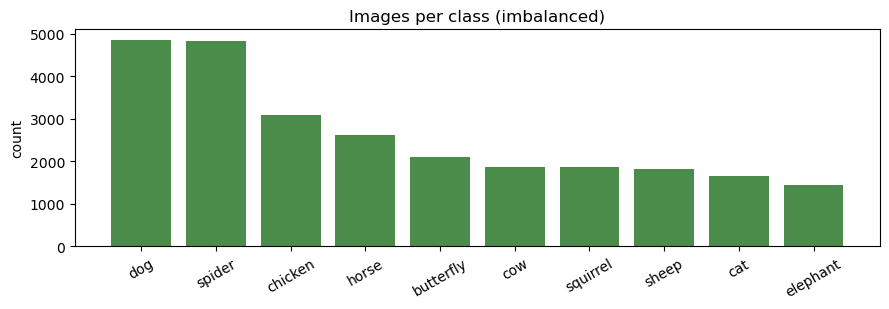

In [6]:
IT2EN = {"cane": "dog", "cavallo": "horse", "elefante": "elephant", "farfalla": "butterfly",
         "gallina": "chicken", "gatto": "cat", "mucca": "cow", "pecora": "sheep",
         "ragno": "spider", "scoiattolo": "squirrel"}

full = datasets.ImageFolder(DATA_DIR)          # no transform yet: items are (PIL image, label)
class_names = [IT2EN[c] for c in full.classes]
targets = np.array(full.targets)
NUM_CLASSES = len(class_names)

print(f"{len(full)} images, {NUM_CLASSES} classes")
counts = np.bincount(targets)
plt.figure(figsize=(9, 3.2))
order = np.argsort(counts)[::-1]
plt.bar([class_names[i] for i in order], counts[order], color="#4c8c4a")
plt.title("Images per class (imbalanced)"); plt.ylabel("count"); plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

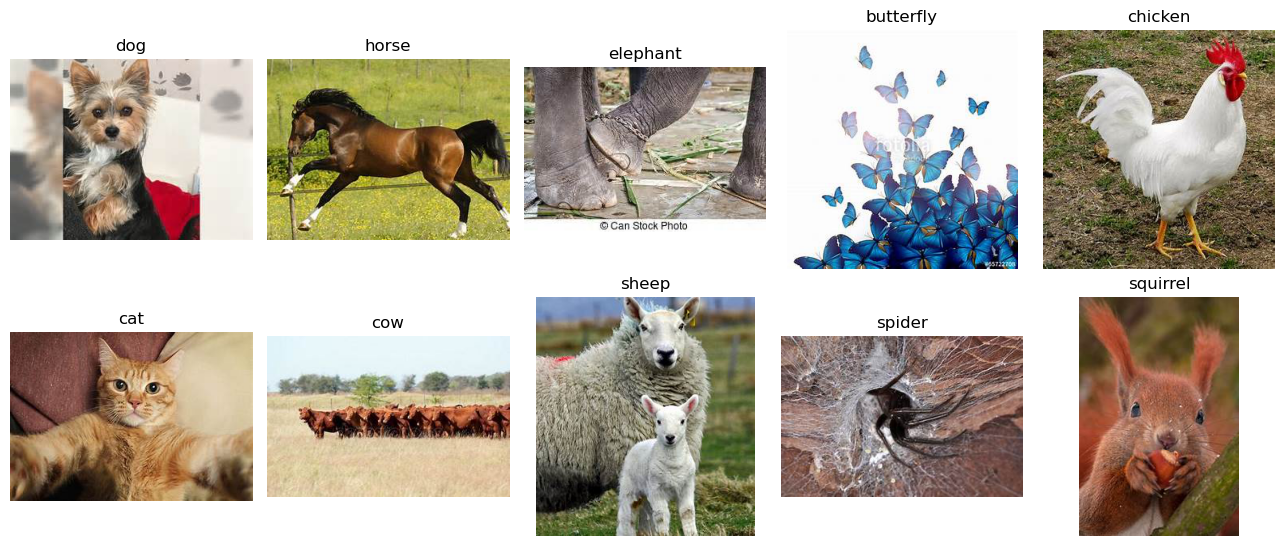

In [7]:
# One sample per class
fig, axes = plt.subplots(2, 5, figsize=(13, 5.5))
for k, ax in enumerate(axes.ravel()):
    i = np.where(targets == k)[0][0]
    ax.imshow(Image.open(full.samples[i][0]).convert("RGB"))
    ax.set_title(class_names[k]); ax.axis("off")
plt.tight_layout(); plt.show()

## 3. Split and preprocessing
Stratified 70/15/15 so every class appears in the same proportion in each split. Augmentation is applied to the training set only.

In [8]:
idx = np.arange(len(targets))
train_idx, temp_idx = train_test_split(idx, test_size=0.30, stratify=targets, random_state=SEED)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, stratify=targets[temp_idx], random_state=SEED)
print(len(train_idx), len(val_idx), len(test_idx))

IMG = 128
MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)

eval_tf = transforms.Compose([
    transforms.Resize((IMG, IMG)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
aug_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

class TransformSubset(Dataset):
    def __init__(self, base, indices, transform):
        self.base, self.indices, self.transform = base, indices, transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        img, y = self.base[self.indices[i]]
        return self.transform(img), y

# Worker processes misbehave in notebooks on macOS/Windows, so only use them on CUDA machines
NUM_WORKERS = min(4, os.cpu_count() or 1) if device.type == "cuda" else 0

def make_loaders(augment, batch_size=64):
    train_ds = TransformSubset(full, train_idx, aug_tf if augment else eval_tf)
    val_ds = TransformSubset(full, val_idx, eval_tf)
    test_ds = TransformSubset(full, test_idx, eval_tf)
    kw = dict(batch_size=batch_size, num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"))
    return (DataLoader(train_ds, shuffle=True, **kw),
            DataLoader(val_ds, shuffle=False, **kw),
            DataLoader(test_ds, shuffle=False, **kw))

18325 3927 3927


## 4. Model
Four blocks of two 3x3 convolutions and a max-pool, then global average pooling and a small classifier. `use_bn` and `dropout` let us build a plain baseline and an improved version from the same class.

In [9]:
class CNN(nn.Module):
    def __init__(self, num_classes, use_bn=True, dropout=0.4, widths=(32, 64, 128, 256)):
        super().__init__()
        layers, in_ch = [], 3
        for w in widths:
            for _ in range(2):
                layers.append(nn.Conv2d(in_ch, w, kernel_size=3, padding=1, bias=not use_bn))
                if use_bn:
                    layers.append(nn.BatchNorm2d(w))
                layers.append(nn.ReLU())
                in_ch = w
            layers.append(nn.MaxPool2d(2))
        self.features = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout), nn.Linear(in_ch, 128), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(128, num_classes),
        )
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")

    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def trace_shapes(model, size=IMG):
    model.eval()
    x = torch.zeros(1, 3, size, size)
    print(f"{'input':<10} -> {tuple(x.shape[1:])}")
    with torch.no_grad():
        for layer in model.features:
            x = layer(x)
            if isinstance(layer, (nn.Conv2d, nn.MaxPool2d)):
                print(f"{layer.__class__.__name__:<10} -> {tuple(x.shape[1:])}")

demo = CNN(NUM_CLASSES)
trace_shapes(demo)
print("Trainable parameters:", f"{count_params(demo):,}")
# For comparison: the first layer of an MLP on a flattened 128x128x3 image with 128 hidden units
print("First MLP layer alone:", f"{IMG * IMG * 3 * 128:,}")
del demo

input      -> (3, 128, 128)
Conv2d     -> (32, 128, 128)
Conv2d     -> (32, 128, 128)
MaxPool2d  -> (32, 64, 64)
Conv2d     -> (64, 64, 64)
Conv2d     -> (64, 64, 64)
MaxPool2d  -> (64, 32, 32)
Conv2d     -> (128, 32, 32)
Conv2d     -> (128, 32, 32)
MaxPool2d  -> (128, 16, 16)
Conv2d     -> (256, 16, 16)
Conv2d     -> (256, 16, 16)
MaxPool2d  -> (256, 8, 8)
Trainable parameters: 1,207,402
First MLP layer alone: 6,291,456


## 5. Training loop

In [10]:
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for x, y in loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            out = model(x)
            loss = criterion(out, y)
            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            n += x.size(0)
    return total_loss / n, correct / n

def fit(model, loaders, epochs, lr=1e-3, name="model"):
    train_dl, val_dl, _ = loaders
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    hist = {k: [] for k in ["train_loss", "val_loss", "train_acc", "val_acc"]}
    best_acc, best_state = 0.0, None
    for ep in range(1, epochs + 1):
        t0 = time.time()
        tl, ta = run_epoch(model, train_dl, criterion, optimizer)
        vl, va = run_epoch(model, val_dl, criterion)
        scheduler.step()
        for k, v in zip(hist, [tl, vl, ta, va]):
            hist[k].append(v)
        if va > best_acc:
            best_acc, best_state = va, copy.deepcopy(model.state_dict())
        print(f"[{name}] epoch {ep:02d}/{epochs}  train {tl:.3f}/{ta:.3f}  val {vl:.3f}/{va:.3f}  ({time.time() - t0:.0f}s)")
    model.load_state_dict(best_state)
    torch.save(best_state, f"{name}.pt")
    print(f"[{name}] best val acc: {best_acc:.4f}")
    return hist

## 6. Experiment: plain CNN vs improved CNN
Same architecture and optimizer. The improved version adds BatchNorm, dropout and data augmentation.

In [ ]:
EPOCHS = 15

loaders_plain = make_loaders(augment=False)
baseline = CNN(NUM_CLASSES, use_bn=False, dropout=0.0).to(device)
print("Baseline params:", f"{count_params(baseline):,}")
hist_base = fit(baseline, loaders_plain, EPOCHS, name="baseline")

Baseline params: 1,206,442
[baseline] epoch 01/15  train 2.173/0.198  val 2.104/0.253  (62s)
[baseline] epoch 02/15  train 1.924/0.314  val 1.665/0.410  (61s)
[baseline] epoch 03/15  train 1.584/0.440  val 1.478/0.478  (61s)
[baseline] epoch 04/15  train 1.381/0.507  val 1.333/0.528  (61s)
[baseline] epoch 05/15  train 1.213/0.573  val 1.257/0.570  (60s)
[baseline] epoch 06/15  train 1.080/0.625  val 1.080/0.638  (60s)
[baseline] epoch 07/15  train 0.962/0.662  val 1.078/0.627  (62s)
[baseline] epoch 08/15  train 0.852/0.707  val 0.981/0.679  (60s)
[baseline] epoch 09/15  train 0.757/0.736  val 0.898/0.704  (61s)
[baseline] epoch 10/15  train 0.662/0.776  val 0.892/0.707  (59s)
[baseline] epoch 11/15  train 0.589/0.800  val 0.838/0.728  (59s)
[baseline] epoch 12/15  train 0.530/0.820  val 0.837/0.735  (59s)
[baseline] epoch 13/15  train 0.471/0.842  val 0.845/0.737  (59s)
[baseline] epoch 14/15  train 0.437/0.853  val 0.815/0.744  (60s)
[baseline] epoch 15/15  train 0.418/0.861  val 0.

In [12]:
loaders_aug = make_loaders(augment=True)
improved = CNN(NUM_CLASSES, use_bn=True, dropout=0.4).to(device)
print("Improved params:", f"{count_params(improved):,}")
hist_imp = fit(improved, loaders_aug, EPOCHS, name="improved")

Improved params: 1,207,402
[improved] epoch 01/15  train 1.899/0.327  val 1.905/0.347  (71s)
[improved] epoch 02/15  train 1.521/0.466  val 1.962/0.399  (66s)
[improved] epoch 03/15  train 1.341/0.531  val 1.496/0.496  (66s)
[improved] epoch 04/15  train 1.235/0.572  val 1.412/0.525  (67s)
[improved] epoch 05/15  train 1.133/0.609  val 1.666/0.492  (66s)
[improved] epoch 06/15  train 1.031/0.648  val 1.006/0.639  (66s)
[improved] epoch 07/15  train 0.965/0.673  val 1.098/0.637  (67s)
[improved] epoch 08/15  train 0.892/0.698  val 0.883/0.699  (67s)
[improved] epoch 09/15  train 0.828/0.724  val 0.819/0.724  (65s)
[improved] epoch 10/15  train 0.783/0.736  val 0.782/0.732  (65s)
[improved] epoch 11/15  train 0.731/0.756  val 0.721/0.751  (65s)
[improved] epoch 12/15  train 0.685/0.772  val 0.656/0.788  (66s)
[improved] epoch 13/15  train 0.643/0.784  val 0.666/0.780  (67s)
[improved] epoch 14/15  train 0.630/0.789  val 0.593/0.805  (67s)
[improved] epoch 15/15  train 0.621/0.795  val 0.

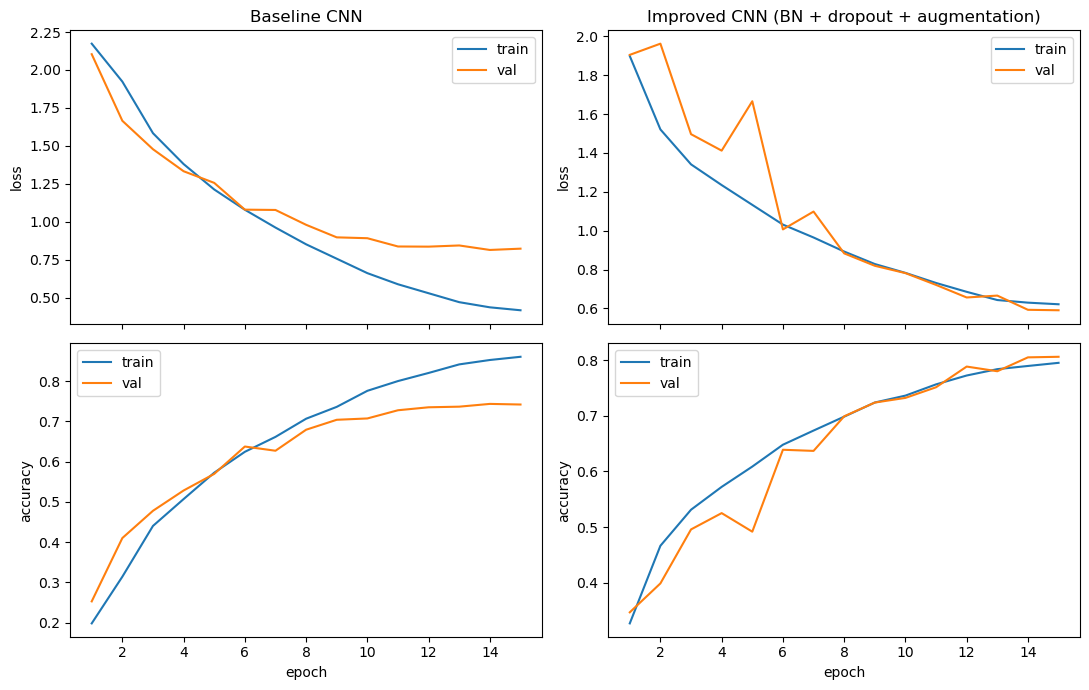

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
for col, (title, h) in enumerate([("Baseline CNN", hist_base), ("Improved CNN (BN + dropout + augmentation)", hist_imp)]):
    ep = range(1, len(h["train_loss"]) + 1)
    axes[0, col].plot(ep, h["train_loss"], label="train"); axes[0, col].plot(ep, h["val_loss"], label="val")
    axes[0, col].set_title(title); axes[0, col].set_ylabel("loss"); axes[0, col].legend()
    axes[1, col].plot(ep, h["train_acc"], label="train"); axes[1, col].plot(ep, h["val_acc"], label="val")
    axes[1, col].set_ylabel("accuracy"); axes[1, col].set_xlabel("epoch"); axes[1, col].legend()
plt.tight_layout(); plt.show()

## 7. Test-set evaluation

In [14]:
@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    ys, ps, cs = [], [], []
    for x, y in loader:
        probs = F.softmax(model(x.to(device)), dim=1).cpu()
        conf, pred = probs.max(1)
        ys.append(y); ps.append(pred); cs.append(conf)
    return torch.cat(ys).numpy(), torch.cat(ps).numpy(), torch.cat(cs).numpy()

test_dl = loaders_plain[2]
y_true, y_pred_b, _ = predict_all(baseline, test_dl)
_, y_pred_i, conf_i = predict_all(improved, test_dl)

rows = []
for name, yp in [("Baseline", y_pred_b), ("Improved", y_pred_i)]:
    rows.append((name, (yp == y_true).mean(), f1_score(y_true, yp, average="macro")))
print(f"{'model':<10}{'test acc':>10}{'macro F1':>10}")
for name, acc, f1 in rows:
    print(f"{name:<10}{acc:>10.4f}{f1:>10.4f}")

model       test acc  macro F1
Baseline      0.7550    0.7322
Improved      0.8039    0.7844


In [15]:
print(classification_report(y_true, y_pred_i, target_names=class_names, digits=3))

              precision    recall  f1-score   support

         dog      0.797     0.782     0.790       730
       horse      0.769     0.779     0.774       393
    elephant      0.848     0.825     0.836       217
   butterfly      0.853     0.861     0.857       317
     chicken      0.928     0.862     0.894       465
         cat      0.660     0.684     0.672       250
         cow      0.678     0.646     0.662       280
       sheep      0.746     0.722     0.734       273
      spider      0.883     0.923     0.903       723
    squirrel      0.692     0.756     0.723       279

    accuracy                          0.804      3927
   macro avg      0.786     0.784     0.784      3927
weighted avg      0.805     0.804     0.804      3927



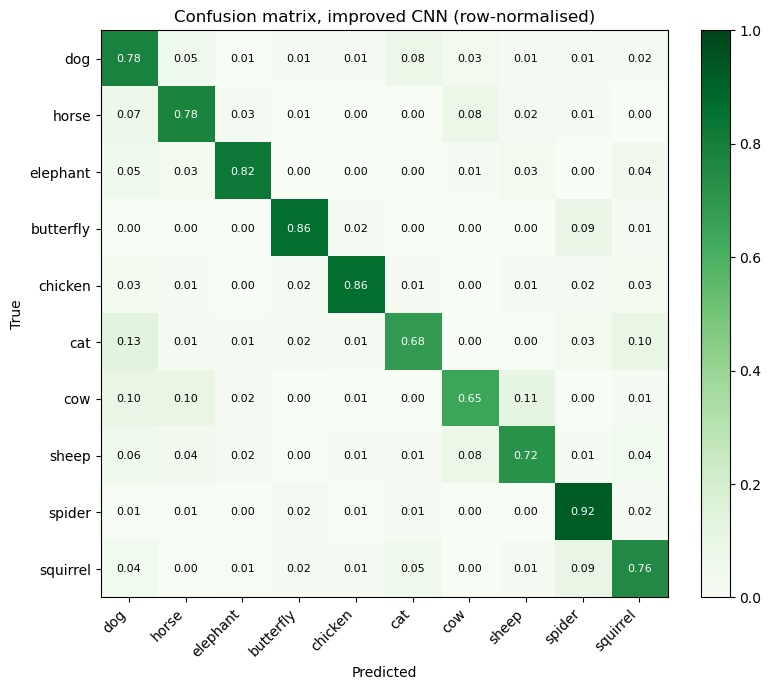

Top confusions (true -> predicted):
  dog -> cat: 55
  dog -> horse: 33
  cat -> dog: 33
  horse -> cow: 32
  cow -> sheep: 30


In [16]:
cm = confusion_matrix(y_true, y_pred_i)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm_norm, cmap="Greens", vmin=0, vmax=1)
ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(class_names)
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center",
                color="white" if cm_norm[i, j] > 0.5 else "black", fontsize=8)
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Confusion matrix, improved CNN (row-normalised)")
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()

# Most common confusions
off = cm.copy(); np.fill_diagonal(off, 0)
top = np.dstack(np.unravel_index(np.argsort(off.ravel())[::-1][:5], off.shape))[0]
print("Top confusions (true -> predicted):")
for i, j in top:
    print(f"  {class_names[i]} -> {class_names[j]}: {off[i, j]}")

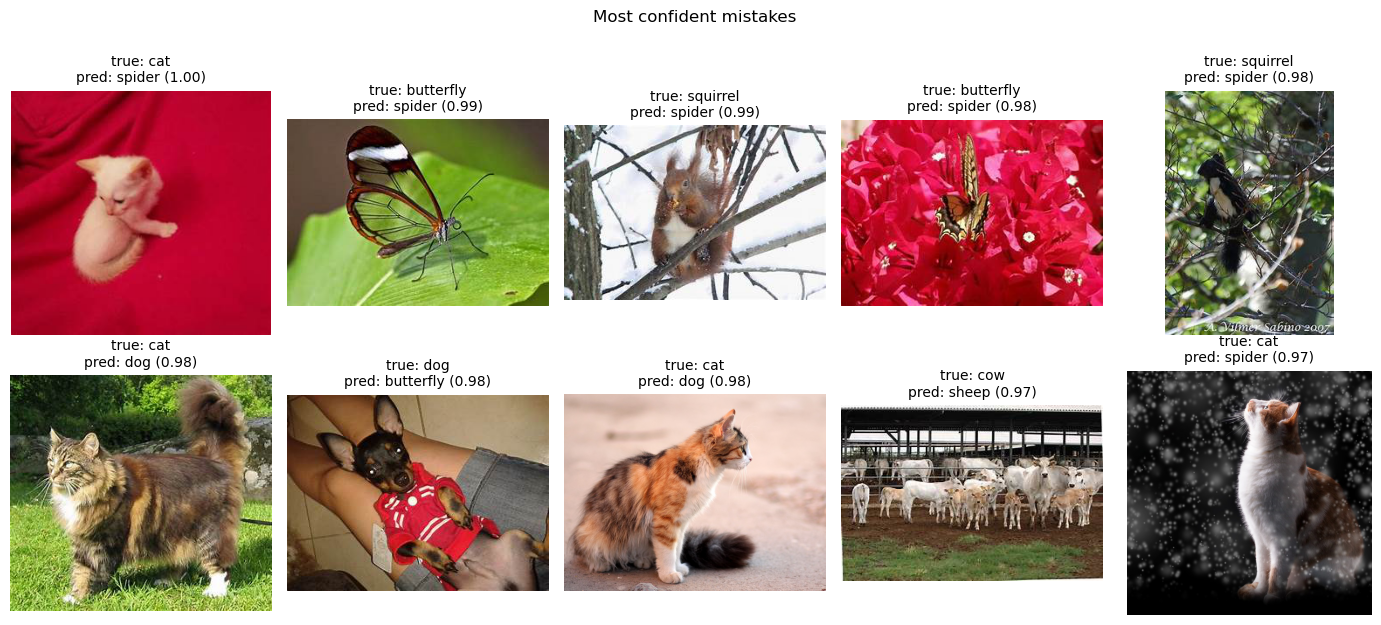

In [17]:
# Most confident mistakes
wrong = np.where(y_pred_i != y_true)[0]
worst = wrong[np.argsort(conf_i[wrong])[::-1][:10]]

fig, axes = plt.subplots(2, 5, figsize=(14, 6.2))
for ax, k in zip(axes.ravel(), worst):
    img = Image.open(full.samples[test_idx[k]][0]).convert("RGB")
    ax.imshow(img); ax.axis("off")
    ax.set_title(f"true: {class_names[y_true[k]]}\npred: {class_names[y_pred_i[k]]} ({conf_i[k]:.2f})", fontsize=10)
plt.suptitle("Most confident mistakes", y=1.0); plt.tight_layout(); plt.show()

## 8. What did the network learn?
First-layer filters, feature maps at three depths, and Grad-CAM heatmaps.

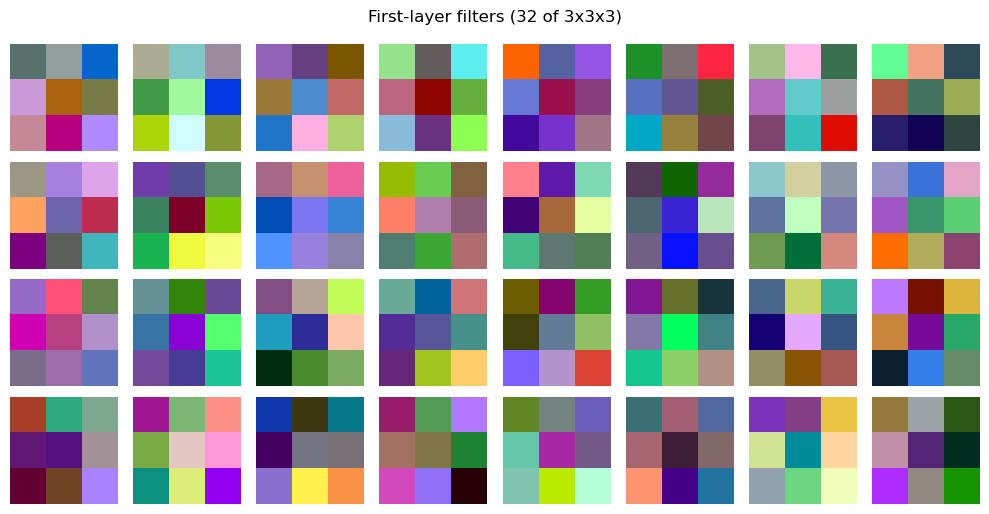

In [18]:
def denorm(t):
    m = torch.tensor(MEAN).view(3, 1, 1); s = torch.tensor(STD).view(3, 1, 1)
    return (t.cpu() * s + m).clamp(0, 1).permute(1, 2, 0).numpy()

# First-layer filters (3x3 RGB)
w = improved.features[0].weight.detach().cpu()
w = (w - w.amin(dim=(1, 2, 3), keepdim=True)) / (w.amax(dim=(1, 2, 3), keepdim=True) - w.amin(dim=(1, 2, 3), keepdim=True) + 1e-8)
fig, axes = plt.subplots(4, 8, figsize=(10, 5.2))
for ax, f in zip(axes.ravel(), w):
    ax.imshow(f.permute(1, 2, 0).numpy(), interpolation="nearest"); ax.axis("off")
plt.suptitle("First-layer filters (32 of 3x3x3)"); plt.tight_layout(); plt.show()

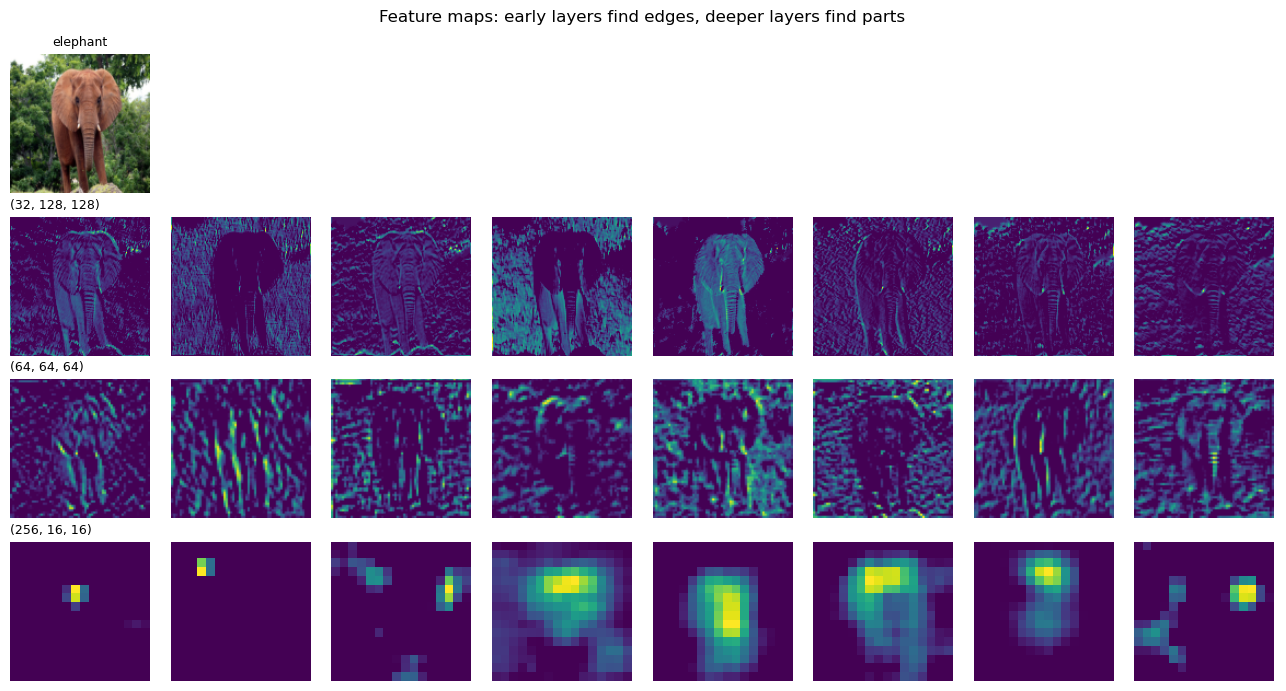

In [19]:
def get_activations(model, x, layer_ids):
    outs, h = {}, x
    for i, layer in enumerate(model.features):
        h = layer(h)
        if i in layer_ids:
            outs[i] = h.detach().cpu()
    return outs

improved.eval()
sample_x, sample_y = next(iter(test_dl))
x1 = sample_x[:1].to(device)

relu_ids = [i for i, l in enumerate(improved.features) if isinstance(l, nn.ReLU)]
chosen = [relu_ids[0], relu_ids[3], relu_ids[7]]      # end of block 1, block 2, block 4
with torch.no_grad():
    acts = get_activations(improved, x1, set(chosen))

fig, axes = plt.subplots(4, 8, figsize=(13, 7))
axes[0, 0].imshow(denorm(x1[0])); axes[0, 0].set_title(class_names[sample_y[0]], fontsize=9)
for ax in axes[0, 1:]: ax.axis("off")
axes[0, 0].axis("off")
for r, layer_id in enumerate(chosen, start=1):
    a = acts[layer_id][0]
    for c in range(8):
        axes[r, c].imshow(a[c], cmap="viridis"); axes[r, c].axis("off")
    axes[r, 0].set_title(f"{tuple(a.shape)}", fontsize=9, loc="left")
plt.suptitle("Feature maps: early layers find edges, deeper layers find parts"); plt.tight_layout(); plt.show()

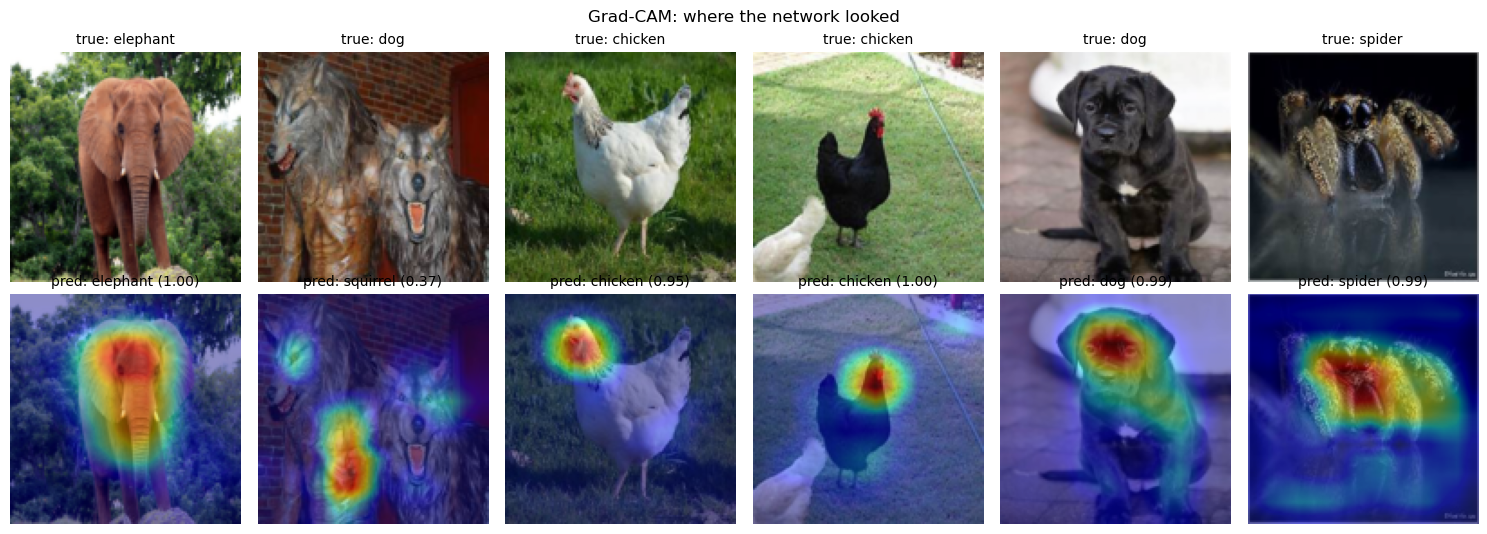

In [20]:
def grad_cam(model, x, target=None):
    model.eval()
    last_relu = [i for i, l in enumerate(model.features) if isinstance(l, nn.ReLU)][-1]
    h = x
    for i, layer in enumerate(model.features):
        h = layer(h)
        if i == last_relu:
            fmap = h
            fmap.retain_grad()
    logits = model.classifier(model.pool(h))
    cls = logits.argmax(1).item() if target is None else target
    model.zero_grad()
    logits[0, cls].backward()
    weights = fmap.grad.mean(dim=(2, 3), keepdim=True)
    cam = F.relu((weights * fmap).sum(dim=1, keepdim=True))
    cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)[0, 0]
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam.detach().cpu().numpy(), cls, F.softmax(logits, dim=1)[0].detach().cpu()

fig, axes = plt.subplots(2, 6, figsize=(15, 5.4))
for k in range(6):
    x = sample_x[k:k + 1].to(device)
    cam, cls, probs = grad_cam(improved, x)
    axes[0, k].imshow(denorm(x[0])); axes[0, k].axis("off")
    axes[0, k].set_title(f"true: {class_names[sample_y[k]]}", fontsize=10)
    axes[1, k].imshow(denorm(x[0])); axes[1, k].imshow(cam, cmap="jet", alpha=0.45); axes[1, k].axis("off")
    axes[1, k].set_title(f"pred: {class_names[cls]} ({probs[cls]:.2f})", fontsize=10)
plt.suptitle("Grad-CAM: where the network looked"); plt.tight_layout(); plt.show()

## 9. Try your own image

In [21]:
def predict_image(path, model=None, topk=3):
    model = model or improved
    img = Image.open(path).convert("RGB")
    x = eval_tf(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        p = F.softmax(model(x), dim=1)[0].cpu()
    top = p.topk(topk)
    plt.figure(figsize=(4, 4)); plt.imshow(img); plt.axis("off")
    plt.title("\n".join(f"{class_names[i]}: {v:.2f}" for v, i in zip(top.values, top.indices)))
    plt.show()

# In Colab: upload a photo from the Files panel, then
# predict_image("/content/my_photo.jpg")

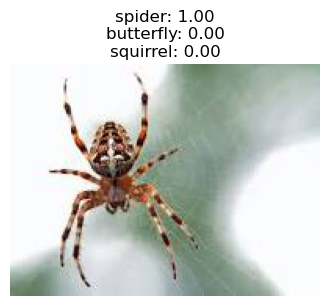

In [23]:
predict_image("/Users/shauryakalra/Documents/MAIN PYTHON EDITOR/ANN _and _DL/Unknown.jpg")